# Station-MAE — Train vs. Test Data Exploration

A short companion to `Data_Exploration.ipynb`, focused on the **train / test split**
actually used by `main.py` (training) and `test.py` (evaluation).

**Contents**
1. Dataloader strategy — training vs. testing/evaluation
2. Dataset characteristics — train split vs. test split
3. Per-station variable panels — characteristics for one station, train vs. test

In [1]:
# ── Config & imports ─────────────────────────────────────────────────────────
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ── Project bootstrap ────────────────────────────────────────────────────────
# This notebook lives in notebooks/ but reads checkpoints/, test_results/ and
# report/ from the project root, and imports data/engine/model from src/.
# Re-running this cell is safe (it only climbs out of notebooks/ once).
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
PROJ = os.getcwd()
if os.path.join(PROJ, "src") not in sys.path:
    sys.path.insert(0, os.path.join(PROJ, "src"))

# Reuse the project's own loader and split definitions so this notebook always
# matches what main.py / test.py actually do.
from data.dataset import (
    load_peakweather,
    VARIABLE_NAMES,          # ['temperature','pressure','humidity','wind_u','wind_v','precipitation']
    TRAIN_YEARS,             # 2017–2021
    VAL_YEARS,               # 2022
    TEST_YEARS,              # 2023–2024
)

# PeakWeather data root — first existing path wins (Renku, home, project folder)
_CANDIDATES = [
    "/home/renku/work/PeakWeatherDataset",
    os.path.expanduser("~/Documents/ETH/_DAS Project/PeakWeatherDataset"),
    os.path.expanduser("~/PeakWeatherDataset"),
    "PeakWeatherDataset",
]
DATA_ROOT = next((p for p in _CANDIDATES if os.path.isdir(p)), _CANDIDATES[-1])

UNITS = {"temperature":"°C","pressure":"hPa","humidity":"%",
         "wind_u":"m/s","wind_v":"m/s","precipitation":"mm"}

plt.rcParams.update({"figure.dpi":110, "font.size":10})
print("Data root  :", DATA_ROOT, "(found)" if os.path.isdir(DATA_ROOT) else "(missing – will download)")
print("Train years:", TRAIN_YEARS)
print("Val   years:", VAL_YEARS)
print("Test  years:", TEST_YEARS)

Data root  : /Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset (found)
Train years: [2017, 2018, 2019, 2020, 2021]
Val   years: [2022]
Test  years: [2023, 2024]


## 1. Dataloader strategy — training vs. testing/evaluation

Both splits build the **same kind of sample**: a 12 h input window
`x` (W = 72 steps @ 10 min) over all stations, plus target snapshots at a grid of
lead-times `Δ` (0 h … 6 h every 30 min → K = 13 horizons; `Δ = 0` is reconstruction).
A random fraction of **whole stations** is hidden from the encoder (station-level
masking). What differs is *how windows are selected* and *how masking is applied*:

| | **Training** (`main.py`) | **Testing / evaluation** (`test.py`) |
|---|---|---|
| Years | 2017–2021 | 2023–2024 (val = 2022) |
| Window selection | `index_mode="random"` — sampled **with replacement** from all contiguity-valid starts; `__getitem__` ignores the DataLoader index | `index_mode="blocks"` — **non-overlapping** windows; test offset by W/4 (≈3 h) so blocks land at 03:00 / 15:00 |
| Epoch size | fixed `random_epoch_size` (e.g. 8 000 windows/epoch) | one pass over all blocks (~1 460 windows) |
| Shuffle | `shuffle=True` | `shuffle=False` (deterministic) |
| Masking | random mask each step, ratio 0.5 | mask-ratio **sweep** (0.0 = pure forecast, 0.5 = trained gap-fill), repeated `gap_fill_repeats` times |
| Normalisation stats | computed on the **train** split | **reuse train stats** (never recomputed on test) |

A window start `i` is valid only if the whole span `[i, i + W-1 + max_Δ]` has no
temporal gaps; per-station missing values are handled separately by the sensor mask.
Below we look at the raw data feeding these two splits.

In [2]:
# ── Load PeakWeather (meteo stations, wind → u/v, 6 variables) ────────────────
# The loader uses imputation_method=None, so gaps are NaN. We ALSO pull the
# explicit availability mask (1 = present, 0 = missing) and apply it, so every
# statistic below is computed on genuinely-observed values only — matching how
# build_observations() in dataset.py derives its mask ( ~isnan ).
ds = load_peakweather(root=DATA_ROOT)

try:
    obs, mask = ds.get_observations(parameters=VARIABLE_NAMES, return_mask=True)
    mask = mask.astype(bool)
    # Force any sensor flagged missing to NaN, even if it held a filled value.
    mask = mask.reindex(columns=obs.columns)
    obs = obs.where(mask)                       # missing sensors → NaN
    print(f"Mask loaded: {100*mask.values.mean():.1f}% of (step, station, var) present")
    _agree = (obs.notna().values == mask.values).mean()
    print(f"NaN vs mask agreement: {100*_agree:.2f}%  (should be ~100%)")
except TypeError:
    # Older API without return_mask — fall back to NaN as the missingness signal
    obs = ds.get_observations(parameters=VARIABLE_NAMES)
    print("return_mask not supported by this peakweather version — using NaN as mask "
          "(equivalent, since imputation_method=None).")

obs.index = pd.to_datetime(obs.index)

stations = obs.columns.get_level_values(0).unique().tolist()
print(f"Stations           : {len(stations)}")
print(f"Timesteps          : {len(obs):,}  ({obs.index[0].date()} → {obs.index[-1].date()})")
print(f"Variables          : {VARIABLE_NAMES}")

# Split the time axis by year, exactly like the dataset class does
year = obs.index.year
split_mask = {
    "train": np.isin(year, TRAIN_YEARS),
    "val":   np.isin(year, VAL_YEARS),
    "test":  np.isin(year, TEST_YEARS),
}

Mask loaded: 93.2% of (step, station, var) present
NaN vs mask agreement: 100.00%  (should be ~100%)
Stations           : 156
Timesteps          : 461,952  (2017-01-01 → 2025-10-13)
Variables          : ['temperature', 'pressure', 'humidity', 'wind_u', 'wind_v', 'precipitation']


In [3]:
# ── Dataset characteristics per split ────────────────────────────────────────
def split_summary(name, m):
    sub = obs.loc[m]
    n_steps = len(sub)
    present = sub.notna().values.mean() * 100      # % of (step,station,var) present
    # Non-overlapping 12h windows ≈ independent samples
    W = 72
    n_windows = n_steps // W
    return {
        "split": name,
        "years": {"train":TRAIN_YEARS,"val":VAL_YEARS,"test":TEST_YEARS}[name],
        "timesteps": n_steps,
        "date_start": sub.index[0].date() if n_steps else None,
        "date_end":   sub.index[-1].date() if n_steps else None,
        "coverage_%": round(present, 1),
        "~indep. 12h windows": n_windows,
    }

summary = pd.DataFrame([split_summary(s, m) for s, m in split_mask.items()]).set_index("split")
display(summary)

,years,timesteps,date_start,date_end,coverage_%,~indep. 12h windows
split,,,,,,
train,"[2017, 2018, 2019, 2020, 2021]",262944,2017-01-01,2021-12-31,93.0,3652
val,[2022],52560,2022-01-01,2022-12-31,93.4,730
test,"[2023, 2024]",105264,2023-01-01,2024-12-31,93.7,1462


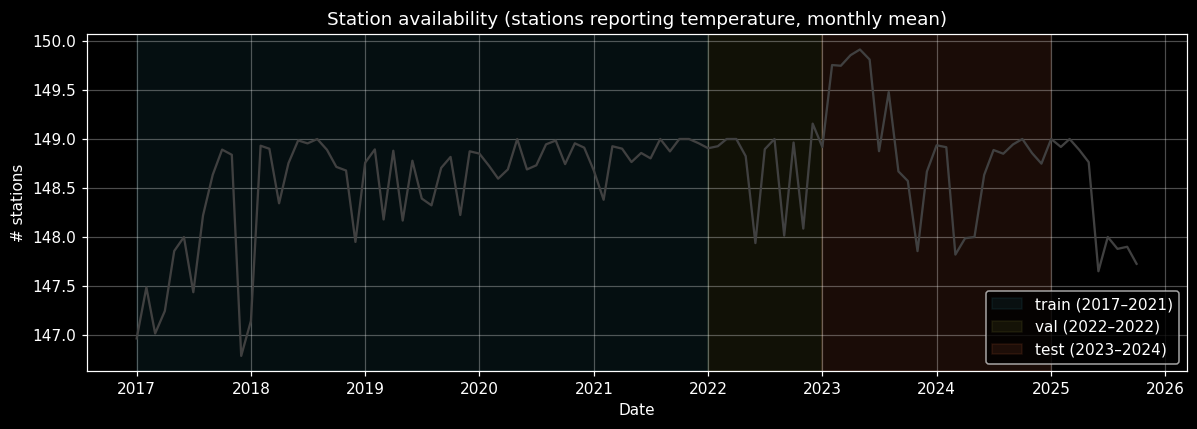

In [4]:
# ── Station availability over time, coloured by split ────────────────────────
# Number of stations reporting temperature, monthly mean.
temp_wide = obs.xs("temperature", axis=1, level=1)     # (datetime × stations)
avail = temp_wide.notna().sum(axis=1)
avail_m = avail.resample("MS").mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(avail_m.index, avail_m.values, color="0.25", lw=1.5)

colors = {"train":"#2E7D8C", "val":"#8E8E38", "test":"#D9663D"}
for name, m in split_mask.items():
    if m.any():
        idx = obs.index[m]
        ax.axvspan(idx.min(), idx.max(), color=colors[name], alpha=0.12,
                   label=f"{name} ({idx.min().year}–{idx.max().year})")

ax.set_title("Station availability (stations reporting temperature, monthly mean)")
ax.set_ylabel("# stations"); ax.set_xlabel("Date")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
# ── Per-variable statistics: train vs test ───────────────────────────────────
def var_stats(m):
    sub = obs.loc[m]
    rows = {}
    for v in VARIABLE_NAMES:
        col = sub.xs(v, axis=1, level=1).values.ravel()
        col = col[~np.isnan(col)]
        rows[v] = {
            "mean": np.mean(col), "std": np.std(col),
            "min": np.min(col), "max": np.max(col),
            "missing_%": 100 * (1 - col.size / sub.xs(v, axis=1, level=1).size),
        }
    return pd.DataFrame(rows).T

stats_train = var_stats(split_mask["train"])
stats_test  = var_stats(split_mask["test"])

compare = pd.concat({"TRAIN (2017–21)": stats_train,
                     "TEST (2023–24)":  stats_test}, axis=1)
display(compare.style.format("{:.2f}")
        .set_caption("Per-variable distribution — train vs test (all stations pooled)"))

## 2. Per-station variable panels

Pick one station and compare its variable characteristics between the training
period (2017–2021) and the test period (2023–2024). This surfaces distribution
shift (e.g. a warmer test period, sensor changes) that the model must handle at
evaluation time.

In [6]:
# ── Choose a station ─────────────────────────────────────────────────────────
STATION = "GSB"  # ← change to any station id
print("Selected station:", STATION)

sdf = obs.xs(STATION, axis=1, level=0).copy()   # columns = variables, index = datetime
sdf = sdf.reindex(columns=VARIABLE_NAMES)
s_train = sdf.loc[split_mask["train"]]
s_test  = sdf.loc[split_mask["test"]]
print(f"  train rows: {len(s_train):,}   test rows: {len(s_test):,}")

Selected station: GSB
  train rows: 262,944   test rows: 105,264


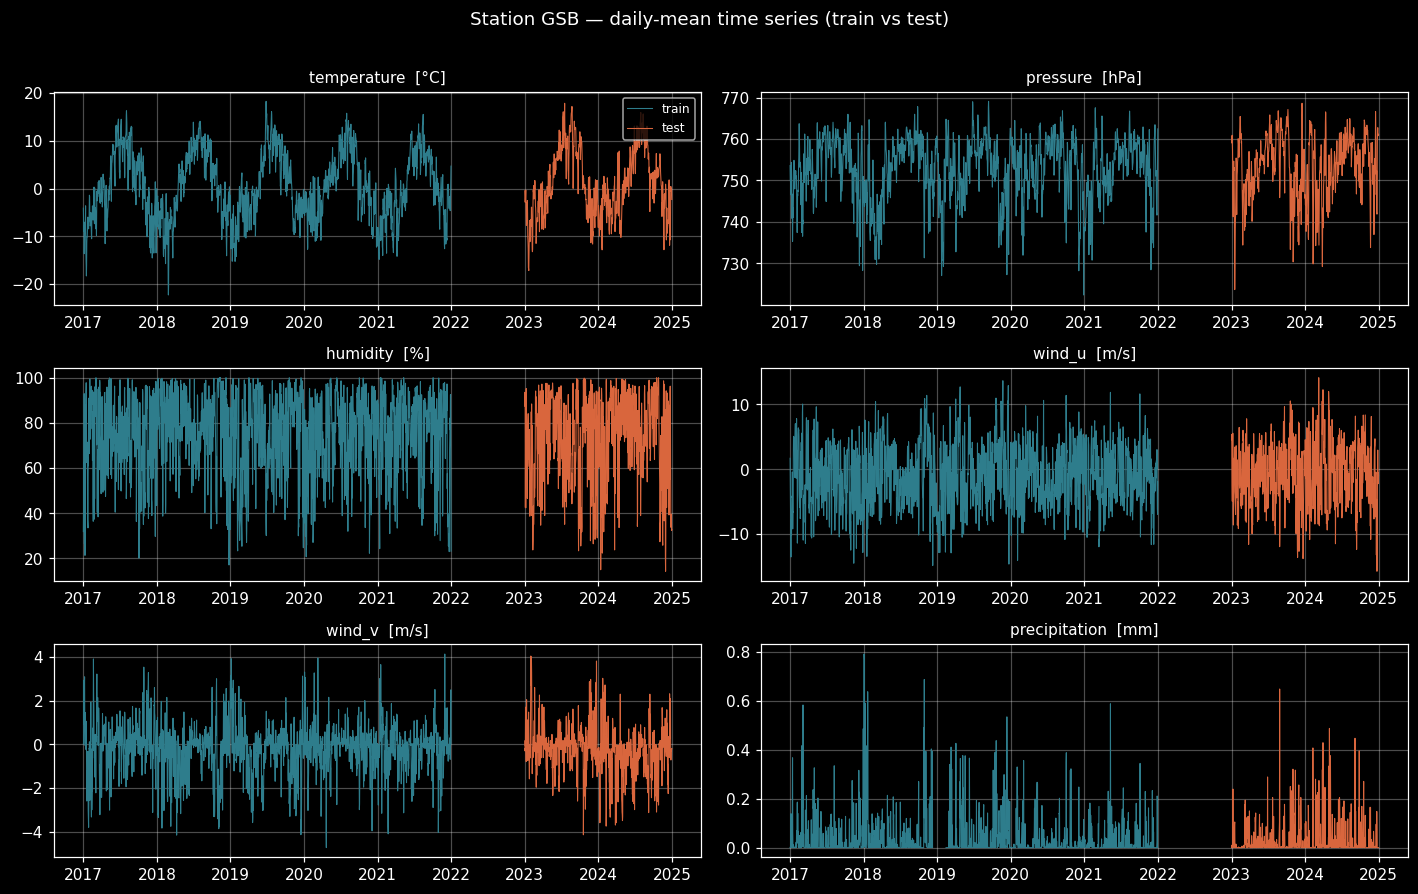

In [7]:
# ── Window 1: time-series panel (daily mean per variable) ────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=False)
for ax, v in zip(axes.ravel(), VARIABLE_NAMES):
    for label, part, c in [("train", s_train, "#2E7D8C"), ("test", s_test, "#D9663D")]:
        daily = part[v].resample("D").mean()
        ax.plot(daily.index, daily.values, color=c, lw=0.7, label=label)
    ax.set_title(f"{v}  [{UNITS[v]}]", fontsize=10)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes.ravel()[0].legend(loc="upper right", fontsize=8)
fig.suptitle(f"Station {STATION} — daily-mean time series (train vs test)", y=1.01)
plt.tight_layout(); plt.show()

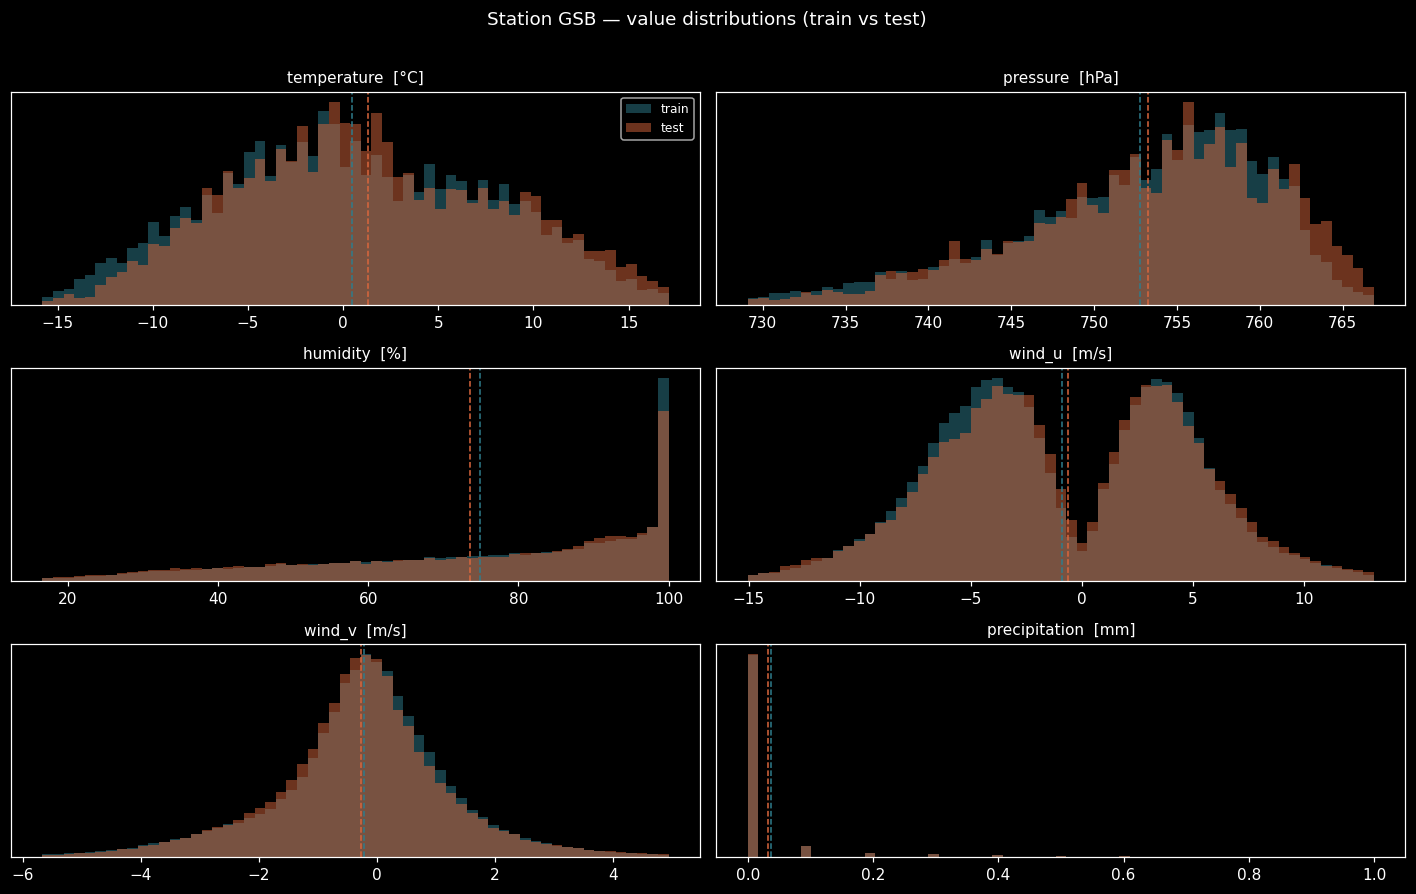

In [8]:
# ── Window 2: distribution panel (histograms per variable) ───────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 8))
for ax, v in zip(axes.ravel(), VARIABLE_NAMES):
    a = s_train[v].dropna().values
    b = s_test[v].dropna().values
    lo = np.nanpercentile(np.concatenate([a, b]), 0.5)
    hi = np.nanpercentile(np.concatenate([a, b]), 99.5)
    bins = np.linspace(lo, hi, 60)
    ax.hist(a, bins=bins, density=True, alpha=0.5, color="#2E7D8C", label="train")
    ax.hist(b, bins=bins, density=True, alpha=0.5, color="#D9663D", label="test")
    ax.axvline(np.mean(a), color="#2E7D8C", ls="--", lw=1)
    ax.axvline(np.mean(b), color="#D9663D", ls="--", lw=1)
    ax.set_title(f"{v}  [{UNITS[v]}]", fontsize=10)
    ax.set_yticks([])
axes.ravel()[0].legend(fontsize=8)
fig.suptitle(f"Station {STATION} — value distributions (train vs test)", y=1.01)
plt.tight_layout(); plt.show()

In [9]:
# ── Per-station numeric comparison (train vs test) ───────────────────────────
def per_station_stats(part):
    out = {}
    for v in VARIABLE_NAMES:
        col = part[v].dropna().values
        out[v] = {"mean": col.mean() if col.size else np.nan,
                  "std":  col.std()  if col.size else np.nan,
                  "missing_%": 100 * (1 - col.size / max(len(part), 1))}
    return pd.DataFrame(out).T

tbl = pd.concat({"TRAIN": per_station_stats(s_train),
                 "TEST":  per_station_stats(s_test)}, axis=1)
# Mean shift = test mean − train mean, in physical units
shift = (per_station_stats(s_test)["mean"] - per_station_stats(s_train)["mean"]).rename("Δmean (test−train)")
display(tbl.style.format("{:.2f}").set_caption(f"Station {STATION} — train vs test"))
display(shift.to_frame().style.format("{:+.2f}"))

,Δmean (test−train)
temperature,+0.82
pressure,+0.50
humidity,-1.25
wind_u,+0.29
wind_v,-0.05
precipitation,-0.00


## 3. Variables >50% missing in training but present in testing

For each `(station, variable)` we compare availability in the **train** years vs the
**test** years. We flag pairs whose training series is **more than 50% missing**
(i.e. present in fewer than half of the available training timesteps) **and** that are
**observed at test time**. These are stations/variables the model barely saw during
training yet must handle at evaluation.

Reference: `dataset.py` also falls back to global normalisation stats when a pair has
fewer than `MIN_OBS = 50` training observations — reported alongside for context.

In [10]:
# ── Stations/variables >50% missing in train but present in test ─────────────
MIN_OBS       = 50    # dataset.py global-norm fallback threshold (for context)
MISS_THRESH   = 50.0  # % of training timesteps that must be missing to flag

n_train = int(split_mask["train"].sum())   # available training timesteps
n_test  = int(split_mask["test"].sum())    # available test timesteps

cnt_train = obs.loc[split_mask["train"]].notna().sum()   # Series: MultiIndex (station, variable)
cnt_test  = obs.loc[split_mask["test"]].notna().sum()

counts = pd.DataFrame({"train_count": cnt_train, "test_count": cnt_test})
counts.index = counts.index.set_names(["station", "variable"])
counts["train_missing_%"] = 100 * (1 - counts["train_count"] / n_train)
counts["test_present_%"]  = 100 * (counts["test_count"] / n_test)

# >50% missing in training AND present in testing
flagged = counts[(counts["train_missing_%"] > MISS_THRESH) & (counts["test_count"] > 0)]
flagged = flagged.reset_index()

print(f"Train timesteps: {n_train:,}   Test timesteps: {n_test:,}")
print(f"Pairs >{MISS_THRESH:.0f}% missing in train but present in test: "
      f"{len(flagged)} (station, variable)\n")

# Per-station rollup: which variables are affected at each station
if len(flagged):
    rollup = (flagged.groupby("station")["variable"]
                     .apply(lambda s: ", ".join(sorted(s)))
                     .rename("variables_>50%_missing_in_train")
                     .reset_index())
    rollup["n_variables"] = rollup["variables_>50%_missing_in_train"].str.count(",") + 1
    display(rollup.sort_values("n_variables", ascending=False).reset_index(drop=True))

    # Full detail with percentages
    detail = (flagged.sort_values(["train_missing_%", "station"], ascending=[False, True])
                     [["station", "variable", "train_count", "train_missing_%",
                       "test_count", "test_present_%"]]
                     .round(1).reset_index(drop=True))
    display(detail)
    out_csv = "train_missing50_test_present.csv"
    detail.to_csv(out_csv, index=False)
    print(f"\nSaved detailed list → {out_csv}")
else:
    print("None — no (station, variable) is >50% missing in training while present in test.")

Train timesteps: 262,944   Test timesteps: 105,264
Pairs >50% missing in train but present in test: 9 (station, variable)



,station,variables_>50%_missing_in_train,n_variables
0,PFA,"humidity, precipitation, pressure, temperature...",6
1,LAE,"wind_u, wind_v",2
2,GES,pressure,1


,station,variable,train_count,train_missing_%,test_count,test_present_%
0,GES,pressure,0,100.0,81434,77.4
1,LAE,wind_u,0,100.0,105169,99.9
2,LAE,wind_v,0,100.0,105169,99.9
3,PFA,temperature,0,100.0,105086,99.8
4,PFA,pressure,0,100.0,105264,100.0
5,PFA,humidity,0,100.0,105264,100.0
6,PFA,wind_u,0,100.0,105264,100.0
7,PFA,wind_v,0,100.0,105264,100.0
8,PFA,precipitation,0,100.0,105264,100.0



Saved detailed list → train_missing50_test_present.csv


## 4. Data quality & consistency checks

Dataset only — no model output. The aim is to find **discrepancies in the data itself**:
stations whose behaviour changes between years, implausible values, stuck sensors, and
inconsistencies between the train and test periods.

Everything here **flags and lists**; nothing is excluded automatically.

### 4a. Network climatology by year — the common-mode signal

Network-mean value per variable per year. This is *real* climate variability, shared by
all stations. It is the reference that the next section subtracts, so that a station's
drift can be separated from a genuinely warm or dry year.

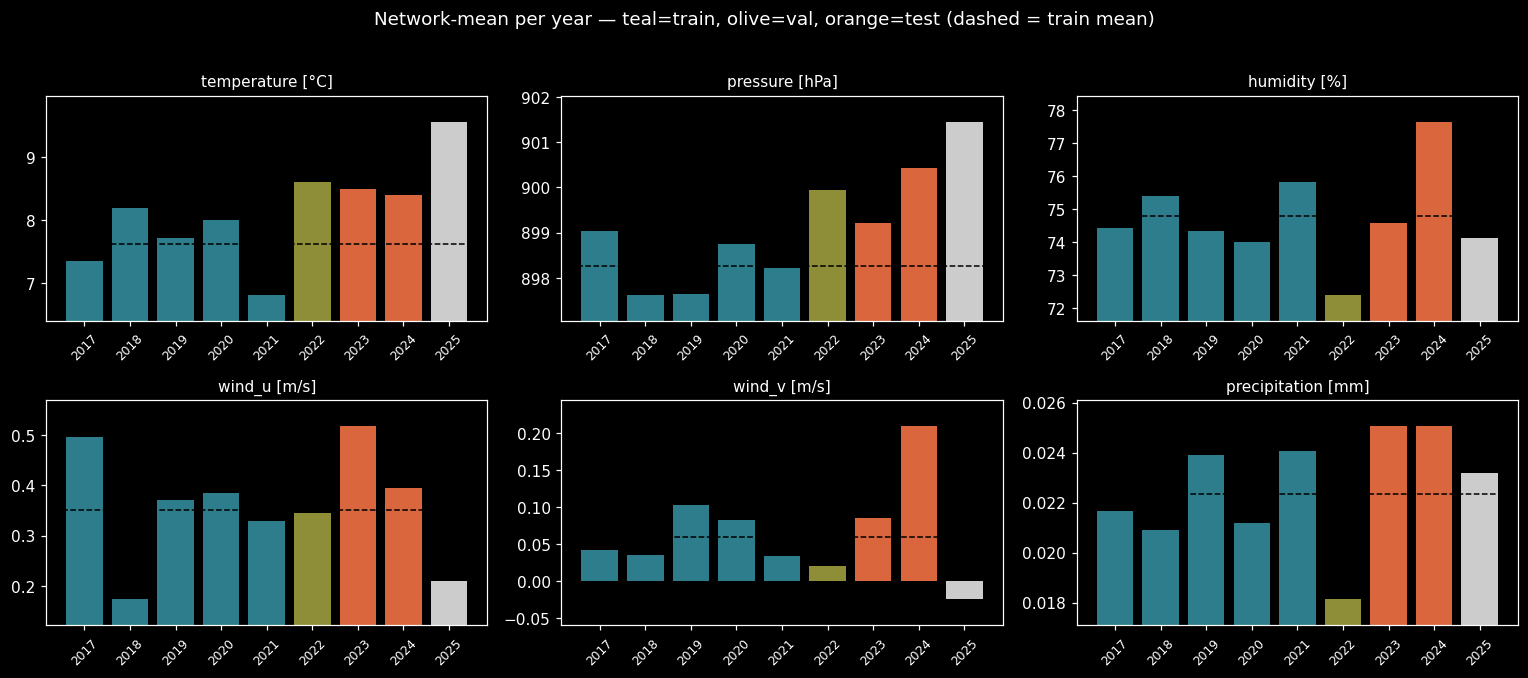

,train mean,test mean,Δ (test − train)
temperature,+7.62,+8.45,+0.83
pressure,+898.25,+899.83,+1.57
humidity,+74.80,+76.12,+1.32
wind_u,+0.35,+0.46,+0.11
wind_v,+0.06,+0.15,+0.09
precipitation,+0.02,+0.03,+0.00


In [12]:
# ── Season labels + network-mean climatology per year ────────────────────────
def _season(m):
    return "DJF" if m in (12,1,2) else "MAM" if m in (3,4,5) else "JJA" if m in (6,7,8) else "SON"

season = pd.Series([_season(m) for m in obs.index.month], index=obs.index, name="season")
yr     = pd.Series(obs.index.year, index=obs.index, name="year")
SEASONS = ["DJF","MAM","JJA","SON"]

yearly = {v: obs.xs(v, axis=1, level=1).mean(axis=1).groupby(obs.index.year).mean()
          for v in VARIABLE_NAMES}
ydf = pd.DataFrame(yearly)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, v in zip(axes.ravel(), VARIABLE_NAMES):
    ax.bar(ydf.index, ydf[v].values,
           color=["#2E7D8C" if y in TRAIN_YEARS else
                  "#8E8E38" if y in VAL_YEARS   else
                  "#D9663D" if y in TEST_YEARS  else "#cccccc" for y in ydf.index])
    ax.axhline(ydf.loc[[y for y in ydf.index if y in TRAIN_YEARS], v].mean(),
               color="k", ls="--", lw=1)
    ax.set_title(f"{v} [{UNITS[v]}]", fontsize=10)
    ax.set_xticks(ydf.index); ax.set_xticklabels(ydf.index, rotation=45, fontsize=8)
    lo, hi = np.nanmin(ydf[v]), np.nanmax(ydf[v]); pad = 0.15*(hi-lo+1e-9)
    ax.set_ylim(lo-pad, hi+pad)
fig.suptitle("Network-mean per year — teal=train, olive=val, orange=test "
             "(dashed = train mean)", y=1.02)
plt.tight_layout(); plt.show()

_shift = pd.DataFrame({
    "train mean": ydf.loc[[y for y in ydf.index if y in TRAIN_YEARS]].mean(),
    "test mean":  ydf.loc[[y for y in ydf.index if y in TEST_YEARS]].mean()})
_shift["Δ (test − train)"] = _shift["test mean"] - _shift["train mean"]
display(_shift.style.format("{:+.2f}").set_caption(
    "Climatological shift train → test (network mean, not a station problem)"))

### 4b. Per-station seasonal anomaly, year over year

For every (station, variable, season, year) we take the station mean and subtract the
**network mean for that same season and year**. What remains is the station's own
signature — a high alpine station is simply always colder than the network, so its
anomaly should be roughly *constant over time*.

**A station whose anomaly changes between years is the thing we are looking for**: that
is instrument drift, a sensor swap or a relocation, not weather.

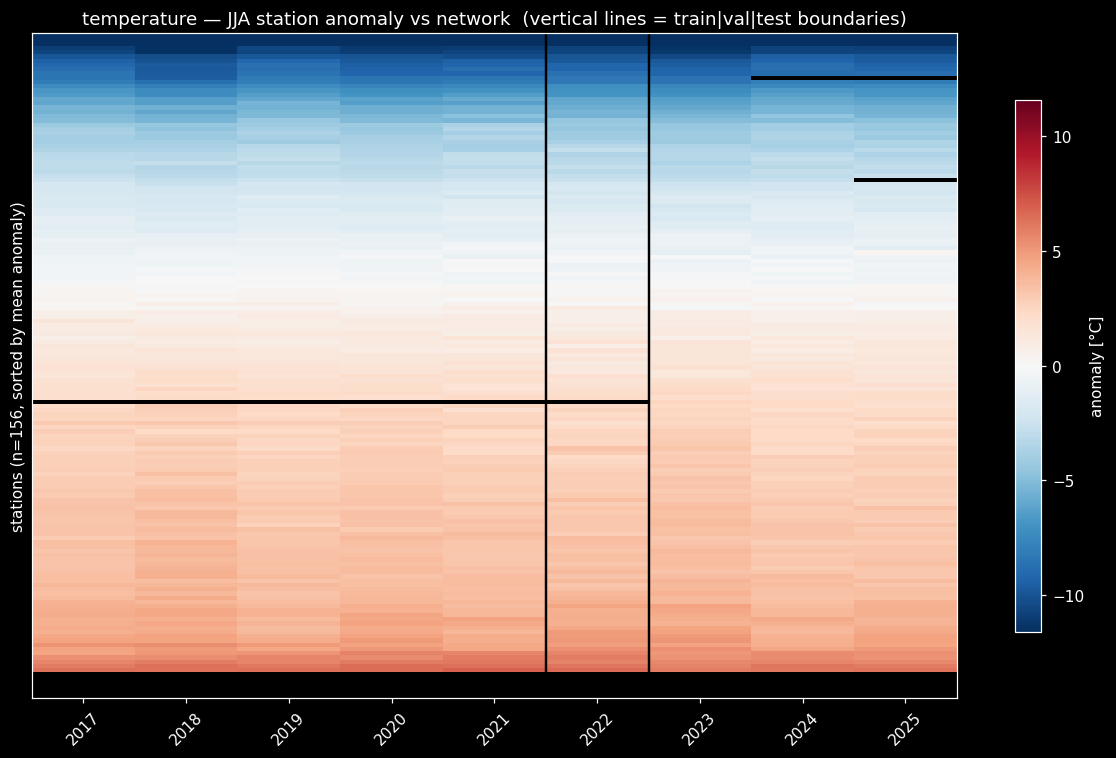

Horizontal stripes of constant colour = stable station.  A row that changes colour part-way through = the station changed.


In [13]:
# ── Station × year anomaly (relative to the network, per season) ─────────────
QC_VAR    = "temperature"     # ← change to inspect another variable
QC_SEASON = "JJA"             # ← DJF / MAM / JJA / SON

def station_season_anomaly(v, seas):
    """(station × year) anomaly of station mean vs network mean, for one season."""
    a   = obs.xs(v, axis=1, level=1)                       # (T, N)
    sel = (season == seas).values
    g   = a.loc[sel].groupby(yr.loc[sel].values).mean()    # (years × N) station means
    net = g.mean(axis=1)                                   # (years,) network mean
    return g.sub(net, axis=0)                              # anomaly

anom = station_season_anomaly(QC_VAR, QC_SEASON)
years = list(anom.index)

# order stations by their long-term mean anomaly so the heatmap reads cleanly
order = anom.mean(axis=0).sort_values().index
A = anom[order].T.values                                   # (stations × years)

fig, ax = plt.subplots(figsize=(11, 7))
vmax = np.nanpercentile(np.abs(A), 98)
im = ax.imshow(A, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(years))); ax.set_xticklabels(years, rotation=45)
ax.set_yticks([]); ax.set_ylabel(f"stations (n={A.shape[0]}, sorted by mean anomaly)")
for b, lbl in [(TRAIN_YEARS, "train"), (VAL_YEARS, "val")]:
    if b and b[-1] in years:
        ax.axvline(years.index(b[-1]) + 0.5, color="k", lw=1.6)
ax.set_title(f"{QC_VAR} — {QC_SEASON} station anomaly vs network  "
             f"(vertical lines = train|val|test boundaries)")
plt.colorbar(im, ax=ax, label=f"anomaly [{UNITS[QC_VAR]}]", shrink=0.8)
plt.tight_layout(); plt.show()
print("Horizontal stripes of constant colour = stable station.  "
      "A row that changes colour part-way through = the station changed.")

### 4c. Flagged discontinuities — stations that changed between years

Year-over-year change in the seasonal anomaly, across **all** variables and seasons. A
stable station has near-zero change; large jumps indicate a sensor swap, recalibration
or relocation. Jumps landing on the **train→test boundary** are called out separately,
since those bias evaluation directly.

In [14]:
# ── Flag year-over-year jumps in the station anomaly ─────────────────────────
JUMP_Z = 4.0     # flag |jump| > JUMP_Z × robust sigma of all jumps for that variable

records = []
for v in VARIABLE_NAMES:
    for seas in SEASONS:
        an = station_season_anomaly(v, seas)
        d  = an.diff()                                   # year-over-year change
        vals = d.values[np.isfinite(d.values)]
        if vals.size < 20:
            continue
        sigma = 1.4826 * np.median(np.abs(vals - np.median(vals)))   # robust MAD sigma
        if sigma <= 0:
            continue
        for y in d.index[1:]:
            row = d.loc[y]
            for stn, val in row.items():
                if np.isfinite(val) and abs(val) > JUMP_Z * sigma:
                    records.append({"station": stn, "variable": v, "season": seas,
                                    "year": int(y), "jump": float(val),
                                    "z": float(abs(val)/sigma),
                                    "at_train_test_boundary":
                                        int(y) in (min(TEST_YEARS), min(VAL_YEARS))})
jumps = pd.DataFrame(records)
print(f"Flagged discontinuities (|jump| > {JUMP_Z}× robust σ): {len(jumps)}")

if len(jumps):
    top = jumps.reindex(jumps.z.abs().sort_values(ascending=False).index).head(25)
    display(top.reset_index(drop=True).style.format({"jump":"{:+.2f}","z":"{:.1f}"})
            .set_caption("Largest year-over-year station changes (flagged, not excluded)"))
    per_station = (jumps.groupby("station")
                        .agg(n_flags=("z","size"), max_z=("z","max"),
                             variables=("variable", lambda s: ", ".join(sorted(set(s)))))
                        .sort_values("n_flags", ascending=False))
    display(per_station.head(15).style.format({"max_z":"{:.1f}"})
            .set_caption("Stations with the most flags — candidates for inspection"))
    nb_ = jumps[jumps.at_train_test_boundary]
    print(f"\nFlags landing on a split boundary: {len(nb_)}"
          f"  → these shift the data the model is evaluated on")
    if len(nb_):
        display(nb_.sort_values("z", ascending=False).head(10).reset_index(drop=True))
else:
    print("No discontinuities above threshold — stations look temporally stable.")

Flagged discontinuities (|jump| > 4.0× robust σ): 385


,station,variable,season,year,jump,z,at_train_test_boundary
0,JUN,wind_v,SON,2018,+4.58,14.9,False
1,GSB,wind_u,SON,2018,+5.06,13.4,False
2,GUE,wind_v,SON,2018,+3.98,12.9,False
3,GSB,precipitation,DJF,2019,-0.05,12.8,False
4,DOL,wind_u,JJA,2018,-3.38,11.8,False
5,PFA,pressure,DJF,2023,+5.33,11.8,True
6,GSB,precipitation,DJF,2018,+0.05,11.7,False
7,GUE,wind_v,DJF,2025,+3.24,11.2,False
8,TIT,wind_u,SON,2018,-4.20,11.1,False
9,CHA,wind_u,JJA,2018,-3.10,10.8,False


,n_flags,max_z,variables
station,,,
JUN,23,14.9,"wind_u, wind_v"
SAE,19,9.4,"precipitation, wind_u"
DOL,19,11.8,"precipitation, wind_u, wind_v"
CHA,18,10.8,"wind_u, wind_v"
DIA,17,7.9,"pressure, wind_u, wind_v"
PMA,16,10.3,"precipitation, wind_v"
GSB,16,13.4,"precipitation, wind_u, wind_v"
TIT,15,11.1,"wind_u, wind_v"
MTR,14,10.6,"humidity, wind_u, wind_v"



Flags landing on a split boundary: 38  → these shift the data the model is evaluated on


,station,variable,season,year,jump,z,at_train_test_boundary
0,PFA,pressure,DJF,2023,5.330811,11.760836,True
1,DOL,wind_u,SON,2022,3.074190,8.131924,True
2,DIA,wind_u,SON,2022,2.985916,7.898420,True
3,JUN,wind_v,SON,2022,-2.394237,7.773285,True
4,DOL,wind_u,JJA,2023,2.184192,7.609943,True
5,SAE,precipitation,MAM,2023,0.039579,7.407590,True
6,CHA,wind_u,SON,2022,2.720880,7.197340,True
7,CHA,wind_u,JJA,2023,2.006877,6.992159,True
8,TIT,wind_u,SON,2022,2.621703,6.934994,True
9,SAE,wind_u,SON,2022,2.564323,6.783213,True


### 4d. Implausible values and stuck sensors

Two independent checks:

- **Physical plausibility** — values outside the range the instrument can meaningfully
  report (humidity above 100 %, negative precipitation, and so on).
- **Stuck sensors** — long runs of *identical* consecutive values. The PeakWeather paper
  explicitly warns about frozen anemometers, so this is a documented failure mode.
  Precipitation and sunshine are excluded from this test since legitimate long zero runs
  are normal for them.

In [15]:
# ── Physical range check + constant-run (stuck sensor) detection ─────────────
BOUNDS = {"temperature": (-45, 45), "pressure": (500, 1100), "humidity": (0, 100),
          "wind_u": (-60, 60), "wind_v": (-60, 60), "precipitation": (0, 100)}

rows = {}
for v in VARIABLE_NAMES:
    a  = obs.xs(v, axis=1, level=1).values
    ok = np.isfinite(a)
    lo, hi = BOUNDS[v]
    n_lo = int(((a < lo) & ok).sum()); n_hi = int(((a > hi) & ok).sum())
    rows[v] = {"bounds": f"[{lo}, {hi}]", "below": n_lo, "above": n_hi,
               "% of valid": 100*(n_lo+n_hi)/max(ok.sum(), 1),
               "min": np.nanmin(a), "max": np.nanmax(a)}
display(pd.DataFrame(rows).T.style.format(
    {"below":"{:.0f}","above":"{:.0f}","% of valid":"{:.4f}","min":"{:.1f}","max":"{:.1f}"})
    .set_caption("Physical range violations (whole dataset)"))

# stuck sensors: identical consecutive values for > STUCK_STEPS
STUCK_STEPS = 36                       # 6 h at 10-min resolution
CONTINUOUS  = ["temperature", "pressure", "humidity", "wind_u", "wind_v"]
stuck = []
for v in CONTINUOUS:
    w = obs.xs(v, axis=1, level=1)
    for stn in w.columns:
        s = w[stn].values
        same = np.zeros(len(s), dtype=bool)
        same[1:] = (s[1:] == s[:-1]) & np.isfinite(s[1:])
        if not same.any():
            continue
        d = np.diff(np.concatenate([[0], same.view(np.int8), [0]]))
        st, en = np.where(d == 1)[0], np.where(d == -1)[0]
        runs = en - st
        if runs.size and runs.max() >= STUCK_STEPS:
            stuck.append({"station": stn, "variable": v,
                          "longest_run_h": float(runs.max()*10/60),
                          "n_runs>=6h": int((runs >= STUCK_STEPS).sum())})
stuck = pd.DataFrame(stuck)
print(f"\n(station, variable) pairs with constant runs ≥ {STUCK_STEPS*10/60:.0f} h: {len(stuck)}")
if len(stuck):
    display(stuck.sort_values("longest_run_h", ascending=False).head(20)
            .reset_index(drop=True).style.format({"longest_run_h":"{:.1f}"})
            .set_caption("Possible stuck / frozen sensors (flagged, not excluded)"))

,bounds,below,above,% of valid,min,max
temperature,"[-45, 45]",0,0,0.0000,-31.1,39.3
pressure,"[500, 1100]",0,0,0.0000,623.7,1020.9
humidity,"[0, 100]",0,0,0.0000,0.0,100.0
wind_u,"[-60, 60]",0,0,0.0000,-30.7,32.7
wind_v,"[-60, 60]",0,0,0.0000,-31.7,40.1
precipitation,"[0, 100]",0,0,0.0000,0.0,37.2



(station, variable) pairs with constant runs ≥ 6 h: 266


,station,variable,longest_run_h,n_runs>=6h
0,SRS,humidity,264.2,746
1,LAE,humidity,228.5,418
2,GUT,humidity,211.0,565
3,HAI,humidity,192.2,781
4,MAH,humidity,181.2,587
5,GEN,humidity,164.7,633
6,BIZ,humidity,162.8,1328
7,EBK,humidity,126.3,800
8,EIN,humidity,121.2,559
9,SPF,humidity,117.2,490


### 4e. Station-level outliers, after removing the altitude effect

A high station *should* be colder and at lower pressure — that is physics, not an error.
So we regress each station's mean on its altitude and look at the **residual**: stations
that are anomalous *given their height*. The pressure panel also shows why per-station
normalisation treats pressure so differently from the other variables.

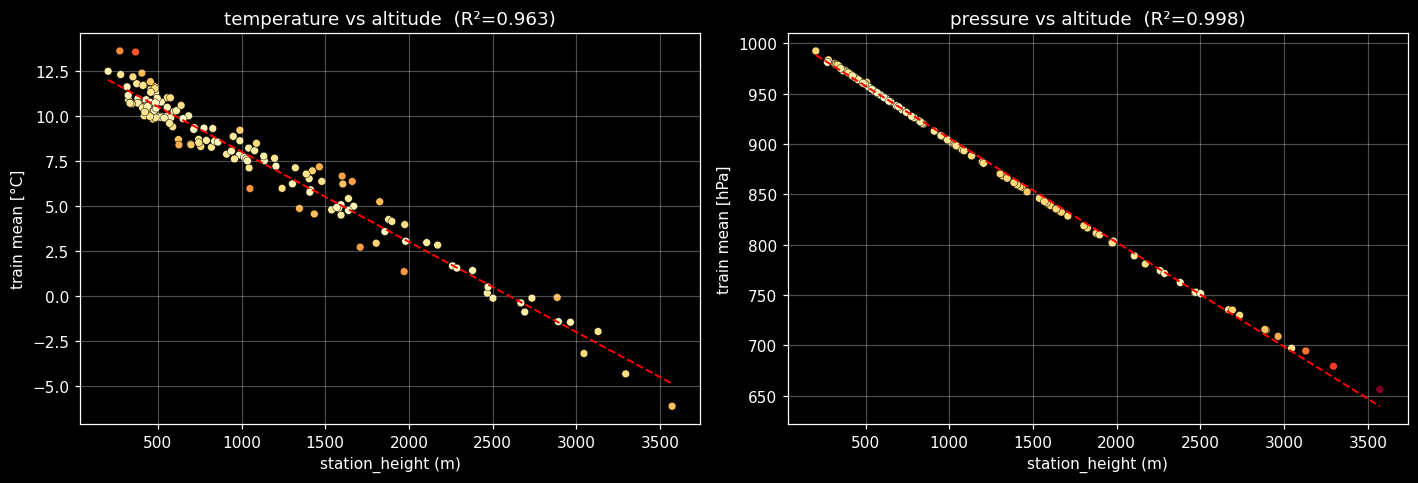

,station,variable,residual,z
0,JUN,pressure,+16.56,+5.1
1,COV,pressure,+11.00,+3.4
2,OTL,temperature,+2.37,+3.1


,per-station σ / network σ
temperature,0.901
pressure,0.090
humidity,0.925
wind_u,0.807
wind_v,0.716
precipitation,0.948


In [16]:
# ── Regress station means on altitude; flag residual outliers ───────────────
alt_col = next((c for c in ["station_height", "elevation", "height"]
                if c in ds.stations_table.columns), None)
tr = obs.loc[split_mask["train"]]

if alt_col is None:
    print("No altitude column in stations_table — skipping.")
else:
    alt_all = ds.stations_table[alt_col].astype(float)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    out_rows = []
    for ax, v in zip(axes, ["temperature", "pressure"]):
        m   = tr.xs(v, axis=1, level=1).mean()
        alt = alt_all.reindex(m.index).astype(float)
        ok  = np.isfinite(m.values) & np.isfinite(alt.values)
        x, y = alt.values[ok], m.values[ok]
        z = np.polyfit(x, y, 1); res = y - np.polyval(z, x)
        sig = 1.4826*np.median(np.abs(res - np.median(res)))
        zsc = res/sig if sig > 0 else np.zeros_like(res)
        ax.scatter(x, y, s=26, c=np.abs(zsc), cmap="YlOrRd", vmin=0, vmax=5,
                   edgecolors="k", linewidths=0.3)
        xs = np.linspace(x.min(), x.max(), 50); ax.plot(xs, np.polyval(z, xs), "r--", lw=1.3)
        r2 = np.corrcoef(x, y)[0,1]**2
        ax.set_title(f"{v} vs altitude  (R²={r2:.3f})")
        ax.set_xlabel(f"{alt_col} (m)"); ax.set_ylabel(f"train mean [{UNITS[v]}]")
        ax.grid(alpha=0.3)
        for stn, zz, rr in zip(np.array(m.index)[ok], zsc, res):
            if abs(zz) > 3:
                out_rows.append({"station": stn, "variable": v,
                                 "residual": float(rr), "z": float(zz)})
    plt.tight_layout(); plt.show()

    if out_rows:
        display(pd.DataFrame(out_rows).sort_values("z", key=np.abs, ascending=False)
                .reset_index(drop=True).style.format({"residual":"{:+.2f}","z":"{:+.1f}"})
                .set_caption("Stations anomalous given their altitude (|z| > 3, flagged only)"))
    else:
        print("No station deviates by more than 3σ from the altitude relationship.")

    # per-station vs global spread — why pressure normalises differently
    ratio = {v: np.nanmedian(tr.xs(v, axis=1, level=1).std().values) /
                np.nanstd(tr.xs(v, axis=1, level=1).values) for v in VARIABLE_NAMES}
    display(pd.Series(ratio, name="per-station σ / network σ").to_frame()
            .style.format("{:.3f}").set_caption(
            "Small ratio ⇒ most of the variance is *between* stations, not within one"))

### 4f. Variable-specific checks and train/test station consistency

Bounded or zero-inflated variables need different treatment from Gaussian ones, and the
station set itself can change between splits — both matter when reading results.

In [17]:
# ── Saturation / zero-inflation / calm wind + station set consistency ────────
checks = {}
h = obs.xs("humidity", axis=1, level=1).values
checks["humidity"] = {"% at 100 (saturated)": 100*np.nanmean(h >= 99.95),
                      "% above 95":           100*np.nanmean(h >= 95)}
p = obs.xs("precipitation", axis=1, level=1).values
checks["precipitation"] = {"% exactly 0 (zero-inflated)": 100*np.nanmean(p == 0),
                           "% above 1 mm/10min":          100*np.nanmean(p > 1)}
spd = np.sqrt(obs.xs("wind_u", axis=1, level=1).values**2 +
              obs.xs("wind_v", axis=1, level=1).values**2)
checks["wind"] = {"% calm (<0.5 m/s, direction ill-defined)": 100*np.nanmean(spd < 0.5),
                  "% above 10 m/s":                          100*np.nanmean(spd > 10)}
for k, d in checks.items():
    print(f"{k}:")
    for kk, vv in d.items():
        print(f"    {kk:45s} {vv:6.2f}%")

# station set consistency between splits
tr_ok = obs.loc[split_mask["train"]].notna().sum() > 0
te_ok = obs.loc[split_mask["test"]].notna().sum() > 0
pairs = pd.DataFrame({"in_train": tr_ok, "in_test": te_ok})
pairs.index = pairs.index.set_names(["station", "variable"])
only_tr = pairs[pairs.in_train & ~pairs.in_test].reset_index()
only_te = pairs[~pairs.in_train & pairs.in_test].reset_index()
print(f"\n(station, variable) present in TRAIN but never in TEST : {len(only_tr)}")
print(f"(station, variable) present in TEST  but never in TRAIN : {len(only_te)}")
if len(only_te):
    display(only_te[["station","variable"]].head(20)
            .style.set_caption("Never seen in training — model has no station-specific "
                               "statistics for these"))
st_tr = {s for s, _ in pairs[pairs.in_train].index}
st_te = {s for s, _ in pairs[pairs.in_test].index}
print(f"\nStations only in train: {sorted(st_tr - st_te)}")
print(f"Stations only in test : {sorted(st_te - st_tr)}")

humidity:
    % at 100 (saturated)                            2.74%
    % above 95                                     17.47%
precipitation:
    % exactly 0 (zero-inflated)                    82.12%
    % above 1 mm/10min                              0.24%
wind:
    % calm (<0.5 m/s, direction ill-defined)        9.36%
    % above 10 m/s                                  1.93%

(station, variable) present in TRAIN but never in TEST : 0
(station, variable) present in TEST  but never in TRAIN : 9


,station,variable
0,PFA,temperature
1,GES,pressure
2,PFA,pressure
3,PFA,humidity
4,LAE,wind_u
5,PFA,wind_u
6,LAE,wind_v
7,PFA,wind_v
8,PFA,precipitation



Stations only in train: []
Stations only in test : ['PFA']


### 4g. Structure of the missing data

Are gaps isolated dropouts or long outages? Relevant because the training pretext hides
**whole stations for a whole window**, which only mirrors reality if real gaps are also
long and station-wide.

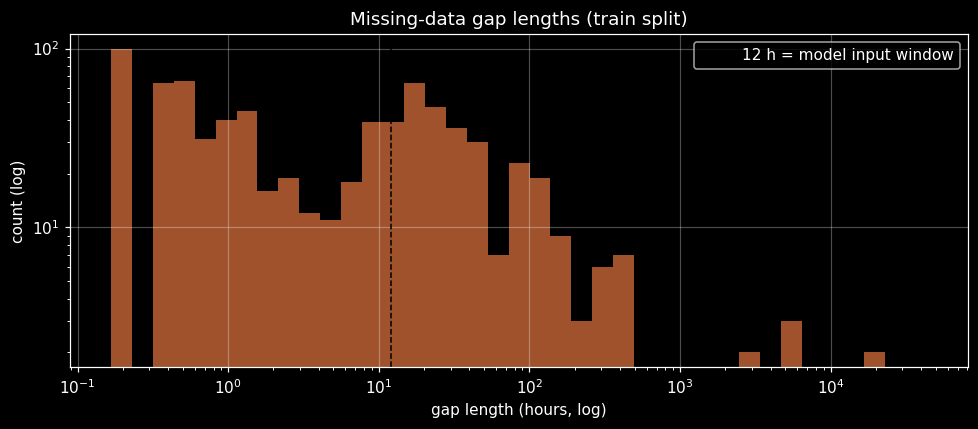

gaps sampled: 775   median 3.50 h   p90 93.27 h   p99 43824.0 h   max 43824 h
fraction of gaps longer than the 12 h input window: 39.4%


In [18]:
# ── Gap-length distribution (train split, sampled station/variable pairs) ────
rng = np.random.default_rng(0)
samp = [(s, v) for s in rng.choice(list(stations), size=min(40, len(stations)),
                                   replace=False) for v in VARIABLE_NAMES]
gaps, tr_vals = [], obs.loc[split_mask["train"]]
for s, v in samp:
    if (s, v) not in tr_vals.columns:
        continue
    isna = tr_vals[(s, v)].isna().values
    if not isna.any():
        continue
    d = np.diff(np.concatenate([[0], isna.view(np.int8), [0]]))
    st, en = np.where(d == 1)[0], np.where(d == -1)[0]
    gaps.extend((en - st).tolist())

gaps = np.array(gaps)
if gaps.size:
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.logspace(0, np.log10(max(gaps.max(), 10)), 40)
    ax.hist(gaps*10/60, bins=bins*10/60, color="#A0522D")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axvline(12, color="k", ls="--", lw=1, label="12 h = model input window")
    ax.set_xlabel("gap length (hours, log)"); ax.set_ylabel("count (log)")
    ax.set_title("Missing-data gap lengths (train split)"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    q = np.percentile(gaps, [50, 90, 99])*10/60
    print(f"gaps sampled: {gaps.size:,}   median {q[0]:.2f} h   p90 {q[1]:.2f} h   "
          f"p99 {q[2]:.1f} h   max {gaps.max()*10/60:.0f} h")
    print(f"fraction of gaps longer than the 12 h input window: {100*np.mean(gaps > 72):.1f}%")
else:
    print("No gaps found in the sampled station/variable pairs.")